In [1]:
import sys
if '../utils' not in sys.path: sys.path.append('../utils')

In [2]:
import json
import re
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from few_shot_trials import TrialsGenerator, EvaluationDatasetBuilder

In [3]:
%run ../utils/results_explore.py

<Figure size 640x480 with 0 Axes>

In [4]:
def get_metadata_from_filename_or_log(filename, conversations):
    """Extracts explicit graph topology and configurations directly from string matches."""
    pattern = r"(LS|MTO|OTM)_M(\d+)_C(\d+)"
    match = re.search(pattern, filename)
    
    if match:
        return {
            "train_structure": match.group(1),
            "members_n": int(match.group(2)),
            "classes_n": int(match.group(3)),
        }
    
    if conversations:
        first_id = conversations[0].get("id", "")
        match = re.search(pattern, first_id)
        if match:
            return {
                "train_structure": match.group(1),
                "members_n": int(match.group(2)),
                "classes_n": int(match.group(3)),
            }
            
    raise ValueError(f"CRITICAL: Failed to parse structural metadata parameters from: {filename}")


def extract_responses_and_telemetry(conversations):
    """Parses conversations to capture raw API metrics and option predictions

    aligned using explicit key index parameters.
    """
    extracted_data = []

    for convo in conversations:
        trial_id = convo.get("id", "")
        if not trial_id.startswith("se_trial_"):
            continue

        idx_match = re.search(r"se_trial_(\d+)", trial_id)
        if not idx_match:
            continue
        trial_index = int(idx_match.group(1))

        metrics_block = convo.get("metrics", {})
        requests = convo.get("requests", [])

        is_empty_or_failed = True
        predicted_option = "NA"
        assistant_text = None

        if requests:
            contents = requests[0].get("contents", [])
            for item in contents:
                if item.get("role") == "CONTENT_ROLE_ASSISTANT":
                    parts = item.get("parts", [])
                    if parts and "text" in parts[0]:
                        assistant_text = parts[0]["text"]
                        break

            if assistant_text is not None and str(assistant_text).strip() != "":
                is_empty_or_failed = False
                matches = re.findall(r"O_[123]", str(assistant_text).upper())
                if matches:
                    predicted_option = matches[-1]
                else:
                    predicted_option = str(assistant_text).strip().upper()

        if is_empty_or_failed or not metrics_block:
            trial_metrics = {
                "trial_index": trial_index,
                "status": "No Response",
                "model_response": "NA",
                "is_silent_failure": 1,
                "inputTokens": 0,
                "outputTokens": 0,
                "inputTokensCostNanodollars": 0.0,
                "outputTokensCostNanodollars": 0.0,
                "totalBackendLatencyMs": np.nan,
                "throughput_tok_sec": np.nan,
            }
        else:
            in_tokens = int(metrics_block.get("inputTokens", 0))
            out_tokens = int(metrics_block.get("outputTokens", 0))
            latency_ms = float(metrics_block.get("totalBackendLatencyMs", 0))

            in_cost_nano = float(metrics_block.get("inputTokensCostNanodollars", 0))
            out_cost_nano = float(metrics_block.get("outputTokensCostNanodollars", 0))
            
            latency_sec = latency_ms / 1000.0
            throughput = (out_tokens / latency_sec) if latency_sec > 0 else np.nan

            trial_metrics = {
                "trial_index": trial_index,
                "status": "Model Response",
                "model_response": predicted_option,
                "is_silent_failure": 0,
                "inputTokens": in_tokens,
                "outputTokens": out_tokens,
                "inputTokensCostNanodollars": in_cost_nano,
                "outputTokensCostNanodollars": out_cost_nano,
                "totalBackendLatencyMs": latency_ms,
                "throughput_tok_sec": throughput,
            }

        extracted_data.append(trial_metrics)

    return pd.DataFrame(extracted_data)


def get_scores_graph_data(model_responses_df):
    """Maps predicted tokens to target answers and extracts clean string representations of nodes."""
    agent_info_df = model_responses_df.copy()
    
    agent_info_df["sample_member"] = agent_info_df["st_sample"].str[0]
    agent_info_df["comparison_member"] = agent_info_df["st_comparison"].str[0]
    
    agent_info_df["response_score"] = (
        agent_info_df["option_answer"] == agent_info_df["model_response"]
    ).astype(int)

    return agent_info_df

In [5]:
class AGIBenchmarkEngine:
    """Consolidates cross-trial model metrics into macro global,

    mid-tier capability property, and micro-level pair-wise node profiles
    with rigorous tracking of total attempted vs. valid non-NA trials.
    """
    def __init__(self, scored_trials_df: pd.DataFrame):
        self.df = scored_trials_df.copy()
        self._preprocess_data()

    def _preprocess_data(self):
        """Enforces structural types, creates total cost metric at trial level,

        and systematically masks metrics on silent failures.
        """
        self.df["response_score"] = self.df["response_score"].astype(float)
        self.df["is_silent_failure"] = self.df["is_silent_failure"].astype(int)
        self.df["totalTokensCostNanodollars"] = (
            self.df["inputTokensCostNanodollars"].fillna(0) +
            self.df["outputTokensCostNanodollars"].fillna(0)
        )

        fail_mask = self.df["is_silent_failure"] == 1
        self.df.loc[fail_mask, "totalBackendLatencyMs"] = np.nan
        self.df.loc[fail_mask, "throughput_tok_sec"] = np.nan
        self.df.loc[fail_mask, "totalTokensCostNanodollars"] = np.nan

    def generate_global_benchmark(self) -> pd.DataFrame:
        """Tier-1: Macro evaluation profiling tracking complete vs attempted allocations."""
        return (
            self.df.groupby(["model", "train_structure", "members_n", "classes_n"])
            .agg(
                accuracy=("response_score", "mean"),
                silent_error_rate=("is_silent_failure", "mean"),
                total_attempted_trials=("model", "count"),
                valid_completed_trials=("totalBackendLatencyMs", "count"),
                median_totalBackendLatencyMs=("totalBackendLatencyMs", "median"),
                median_throughput_tok_sec=("throughput_tok_sec", "median"),
                median_inputTokens=("inputTokens", "median"),
                median_outputTokens=("outputTokens", "median"),
                median_inputTokensCostNanodollars=("inputTokensCostNanodollars", "median"),
                median_outputTokensCostNanodollars=("outputTokensCostNanodollars", "median"),
                median_totalTokensCostNanodollars=("totalTokensCostNanodollars", "median"),
            )
            .reset_index()
        )

    def generate_property_benchmark(self) -> pd.DataFrame:
        """Tier-2: Property profiles evaluated via target non-NA entries."""
        return (
            self.df.groupby(["model", "train_structure", "sample_subset"])
            .agg(
                accuracy=("response_score", "mean"),
                silent_error_rate=("is_silent_failure", "mean"),
                total_attempted_trials=("model", "count"),
                valid_completed_trials=("totalBackendLatencyMs", "count"),
                median_totalBackendLatencyMs=("totalBackendLatencyMs", "median"),
                median_throughput_tok_sec=("throughput_tok_sec", "median"),
                median_inputTokens=("inputTokens", "median"),
                median_outputTokens=("outputTokens", "median"),
                median_inputTokensCostNanodollars=("inputTokensCostNanodollars", "median"),
                median_outputTokensCostNanodollars=("outputTokensCostNanodollars", "median"),
                median_totalTokensCostNanodollars=("totalTokensCostNanodollars", "median"),
            )
            .reset_index()
        )

    def generate_pairwise_benchmark(self) -> pd.DataFrame:
        """Tier-3: Micro-transition maps isolating spatial constraints per edge mapping."""
        pairwise_perf = (
            self.df.groupby(["model", "train_structure", "sample_subset", "sample_member", "comparison_member"])
            .agg(
                accuracy=("response_score", "mean"),
                silent_error_rate=("is_silent_failure", "mean"),
                total_attempted_trials=("model", "count"),
                valid_completed_trials=("totalBackendLatencyMs", "count"),
                median_totalBackendLatencyMs=("totalBackendLatencyMs", "median"),
                median_throughput_tok_sec=("throughput_tok_sec", "median"),
                median_inputTokens=("inputTokens", "median"),
                median_outputTokens=("outputTokens", "median"),
                median_inputTokensCostNanodollars=("inputTokensCostNanodollars", "median"),
                median_outputTokensCostNanodollars=("outputTokensCostNanodollars", "median"),
                median_totalTokensCostNanodollars=("totalTokensCostNanodollars", "median"),
            )
            .reset_index()
        )

        # Enforce exact conditional constraint for stimulus equivalence chains
        pairwise_perf["node_hop_distance"] = pairwise_perf.apply(self._compute_ls_distance, axis=1)
        return pairwise_perf

    @staticmethod
    def _compute_ls_distance(row):
        """Calculates exact stimulus distance strings for LS topologies exclusively."""
        if str(row["train_structure"]).upper() != "LS":
            return np.nan
        
        try:
            pos_sample = ord(str(row["sample_member"]).upper())
            pos_comparison = ord(str(row["comparison_member"]).upper())
            return abs(pos_comparison - pos_sample)
        except Exception:
            return np.nan

In [6]:
def display_pareto_efficiency_plot(df_global):
    """
    Constructs and renders the Pareto Frontier inline.
    Returns the figure object so a subsequent cell can save it to disk.
    """
    # Process Cost from Nanodollars to Microdollars if not already present
    if "total_cost_microdollars" not in df_global.columns:
        df_global["total_cost_microdollars"] = df_global["median_totalTokensCostNanodollars"]/ 1000.0
    
    # Initialize figure canvas
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.grid(True, linestyle="--", alpha=0.3, zorder=0)
    
    # Enforce 'train_structure' nomenclature over the erroneous term 'topology'
    train_structure_order = ["LS", "MTO", "OTM"]
    # palette = sns.color_palette("Set2", n_colors=df_global["model"].nunique())
    palette = sns.color_palette("Set2", n_colors=df_global["model"].nunique())
    
    # Scatter Plot implementation
    sns.scatterplot(
        data=df_global,
        x="total_cost_microdollars",
        y="accuracy",
        hue="model",
        style="train_structure",
        style_order=train_structure_order,
        palette=palette,
        s=120,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=3,
        ax=ax
    )

    # # Dynamic annotation placement for top-performing or highly cost-effective models
    # for _, row in df_global.iterrows():
    #     if row["accuracy"] > 0.8 or row["total_cost_microdollars"] < 1.5:
    #         ax.text(
    #             row["total_cost_microdollars"] + 0.05, 
    #             row["accuracy"] - 0.015, 
    #             f"{row['model']} ({row['train_structure']})", 
    #             fontsize=7, 
    #             alpha=0.8
    #         )

    ax.set_title("Pareto Efficiency Frontier (Accuracy vs. Cost)")
    ax.set_xlabel(r"Median Trial Operational Cost ($\mu$USD)")
    ax.set_ylabel("Macro Evaluation Accuracy")
    ax.set_ylim(0, 1.05)
    
    # Place legend cleanly outside of data boundaries
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    
    # Display the figure inline using IPython context to preserve memory pointers
    display(fig)
    plt.close(fig) # Closes active state to avoid duplicate rendering artifacts
    
    return fig


def display_property_plot(df_property):
    """
    Generates a performance visualization across train structures (LS, MTO, OTM).
    Excludes any spatial node-hop/distance components, focusing on global properties.
    """
    df_property["sample_subset"] = df_property["sample_subset"].str.lower()
    property_order = ["reflexivity", "symmetry", "transitivity"]
    
    # Utilize Seaborn's FacetGrid/CatPlot for multi-dimensional comparison across train structures
    g = sns.catplot(
        data=df_property,
        x="sample_subset",
        y="accuracy",
        hue="model",
        col="train_structure",
        col_order=["LS", "MTO", "OTM"],
        order=property_order,
        kind="bar",
        palette="Set2",
        edgecolor="black",
        linewidth=0.5,
        height=4.5,
        aspect=0.9,
        zorder=3
    )
    
    # Apply clean structural styles to the facets
    for ax in g.axes.flat:
        ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Property Accuracy Score")
        ax.set_xlabel("Property")
        # Correctly labeling columns as Train Structures
        title = ax.get_title().replace("train_structure =", "Train Structure:")
        ax.set_title(title, fontweight="bold")
    
    g.fig.subplots_adjust(top=0.8)
    g.fig.suptitle("Property score Across Train Structures", y=0.95)
    
    # Extract the base figure object, display, and clean up active plotting state
    fig = g.fig
    display(fig)
    plt.close(fig)
    
    return fig

In [7]:
models_files = os.listdir("bench_outputs")
print(len(models_files))
models_files

25


['SEB_Task1_LS_M4_C3-run_id_Run_1_anthropic_claude-opus-4-8default.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_anthropic_claude-sonnet-4-6default.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_deepseek-ai_deepseek-v3.2.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_google_gemini-3.1-pro-preview.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_openai_gpt-5.4-2026-03-05.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_openai_gpt-5.5-2026-04-23.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_qwen_qwen3-next-80b-a3b-instruct.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_xai_grok-4.20-0309-reasoning.run.json',
 'SEB_Task1_LS_M4_C3-run_id_Run_1_zai_glm-5.run.json',
 'SEB_Task2_MTO_M4_C3-run_id_Run_1_anthropic_claude-opus-4-8default.run.json',
 'SEB_Task2_MTO_M4_C3-run_id_Run_1_anthropic_claude-sonnet-4-6default.run.json',
 'SEB_Task2_MTO_M4_C3-run_id_Run_1_google_gemini-3.1-pro-preview.run.json',
 'SEB_Task2_MTO_M4_C3-run_id_Run_1_openai_gpt-5.4-2026-03-05.run.json',
 'SEB_Task2_MTO_M4_C3-run_id_Run_1_open

In [8]:
input_directory = "bench_outputs/"  # Update this folder path inside your Kaggle runtime

In [9]:
master_longform_buffer = []

In [10]:
for file_name in models_files:
    file_path = os.path.join(input_directory, file_name)
    
    if not os.path.exists(file_path):
        print(f"[WARNING] File not found in workspace: {file_path}. Skipping.")
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)

    conversations = json_data.get("conversations", [])
    
    # Isolate target tracking labels
    model_slug = json_data.get("modelVersion", {}).get("slug", "unknown").split("@")[0]
    if model_slug == "unknown":
        model_slug = file_name.split("run_id_Run_1_")[-1].replace(".run.json", "")

    # Extract meta parameters and base outputs
    run_metadata = get_metadata_from_filename_or_log(file_name, conversations)
    out_trials = extract_responses_and_telemetry(conversations)

    # Build testing environments via local environment modules
    generator = TrialsGenerator(**run_metadata)
    builder = EvaluationDatasetBuilder(generator)
    model_responses_df = builder.build_evaluation_dataset()
    
    model_responses_df.drop(
        columns=["few_shot_context", "formatted_test_trial"], 
        inplace=True, 
        errors="ignore"
    )

    # Map nodes back to structural keys
    reverse_translation_map = {v: k for k, v in generator.translation_map.items()}
    for col in ["st_sample", "st_comp1", "st_comp2", "st_comp3", "st_comparison"]:
        if col in model_responses_df.columns:
            model_responses_df[col] = model_responses_df[col].map(reverse_translation_map).fillna(model_responses_df[col])

    # Core position index alignment join step
    model_responses_df = model_responses_df.reset_index().rename(columns={"index": "trial_index"})
    merged_trial_df = pd.merge(model_responses_df, out_trials, on="trial_index", how="inner")

    # Run vectorized scoring calculations
    scored_df = get_scores_graph_data(merged_trial_df)

    # Broadcast structural properties as uniform series variables
    scored_df["model"] = model_slug
    scored_df["train_structure"] = run_metadata["train_structure"]
    scored_df["members_n"] = run_metadata["members_n"]
    scored_df["classes_n"] = run_metadata["classes_n"]

    master_longform_buffer.append(scored_df)

In [11]:
if master_longform_buffer:
    master_scored_df = pd.concat(master_longform_buffer, ignore_index=True)
    print(f"\nUnified evaluation array compiled. Base dimensions: {master_scored_df.shape}")

    # Initialize analysis calculations
    analysis_engine = AGIBenchmarkEngine(master_scored_df)
    
    df_tier1_global = analysis_engine.generate_global_benchmark()
    df_tier2_property = analysis_engine.generate_property_benchmark()
    df_tier3_pairwise = analysis_engine.generate_pairwise_benchmark()

    print("\n>>> DATA ANALYSIS EXTRACTION SUMMARY COMPLETE <<<")
    print(f"Tier 1 (Global Split):   {df_tier1_global.shape[0]} structural profile items.")
    print(f"Tier 2 (Property Split): {df_tier2_property.shape[0]} structural profile items.")
    print(f"Tier 3 (Pairwise Split): {df_tier3_pairwise.shape[0]} structural profile items.")

    df_tier1_global.to_csv("agi_benchmark_global.csv", encoding="utf8")
    df_tier2_property.to_csv("agi_benchmark_property.csv", encoding="utf8")
    df_tier3_pairwise.to_csv("agi_benchmark_pairwise.csv", encoding="utf8")

else:
    print("\n[CRITICAL ERROR] Buffer empty. Verify your data directory input settings paths.")


Unified evaluation array compiled. Base dimensions: (5850, 24)

>>> DATA ANALYSIS EXTRACTION SUMMARY COMPLETE <<<
Tier 1 (Global Split):   25 structural profile items.
Tier 2 (Property Split): 75 structural profile items.
Tier 3 (Pairwise Split): 325 structural profile items.


In [31]:
list(df_tier1_global.model.unique())

['anthropic/claude-opus-4-8',
 'anthropic/claude-sonnet-4-6',
 'deepseek-ai/deepseek-v3.2',
 'google/gemini-3.1-pro-preview',
 'openai/gpt-5.4-2026-03-05',
 'openai/gpt-5.5-2026-04-23',
 'qwen/qwen3-next-80b-a3b-instruct',
 'xai/grok-4.20-0309-reasoning',
 'zai/glm-5']

In [12]:
error_models_dat = df_tier1_global.pivot(
    columns = "train_structure",
    index = "model",
    values = "silent_error_rate"
    )
clean_errors = error_models_dat.dropna()
matching_models_df =clean_errors[(clean_errors < 0.05).all(axis=1)]
passing_models_list = matching_models_df.index.tolist()

passing_models_list

['anthropic/claude-opus-4-8',
 'google/gemini-3.1-pro-preview',
 'openai/gpt-5.4-2026-03-05',
 'openai/gpt-5.5-2026-04-23',
 'qwen/qwen3-next-80b-a3b-instruct',
 'xai/grok-4.20-0309-reasoning']

In [13]:
print(error_models_dat.loc[~error_models_dat.index.isin(passing_models_list)].copy().to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{lrrr}
\toprule
train_structure & LS & MTO & OTM \\
model &  &  &  \\
\midrule
anthropic/claude-sonnet-4-6 & 0.00 & 0.07 & 0.11 \\
deepseek-ai/deepseek-v3.2 & 0.00 & NaN & NaN \\
zai/glm-5 & 0.00 & 0.24 & 0.13 \\
\bottomrule
\end{tabular}



In [14]:
mapping_models = {
    "anthropic/claude-opus-4-8": "Opus",
    "google/gemini-3.1-pro-preview": "Gemini-3.1",
    "openai/gpt-5.4-2026-03-05": "GPT-5.4",
    "openai/gpt-5.5-2026-04-23": "GPT-5.5",
    "qwen/qwen3-next-80b-a3b-instruct": "Qwen3",
    "xai/grok-4.20-0309-reasoning": "Grok-4.20"
    }

In [15]:
macro_accuracy_model = df_tier1_global[df_tier1_global['model'].isin(passing_models_list)].copy()
property_accuracy_model = df_tier2_property[df_tier2_property['model'].isin(passing_models_list)].copy()
pairwise_accuracy_model = df_tier3_pairwise[df_tier3_pairwise['model'].isin(passing_models_list)].copy()

In [16]:
macro_accuracy_model['model'] = macro_accuracy_model['model'].map(mapping_models).fillna(macro_accuracy_model['model'])
property_accuracy_model['model'] = property_accuracy_model['model'].map(mapping_models).fillna(property_accuracy_model['model'])
pairwise_accuracy_model['model'] = pairwise_accuracy_model['model'].map(mapping_models).fillna(pairwise_accuracy_model['model'])


In [17]:
print(
macro_accuracy_model.pivot(
    columns = "train_structure",
    index = "model",
    values = "accuracy"
    ).to_latex(float_format=lambda x: f"{x:.2f}")
    )


\begin{tabular}{lrrr}
\toprule
train_structure & LS & MTO & OTM \\
model &  &  &  \\
\midrule
GPT-5.4 & 0.47 & 0.75 & 0.63 \\
GPT-5.5 & 1.00 & 0.99 & 1.00 \\
Gemini-3.1 & 1.00 & 1.00 & 1.00 \\
Grok-4.20 & 0.98 & 0.92 & 1.00 \\
Opus & 0.66 & 0.95 & 0.94 \\
Qwen3 & 0.33 & 0.52 & 0.49 \\
\bottomrule
\end{tabular}



In [18]:
print(
macro_accuracy_model.pivot(
    columns = "train_structure",
    index = "model",
    values = "median_totalTokensCostNanodollars"
    ).to_latex(float_format=lambda x: f"{x:.2f}")
    )

\begin{tabular}{lrrr}
\toprule
train_structure & LS & MTO & OTM \\
model &  &  &  \\
\midrule
GPT-5.4 & 1612500.00 & 1587500.00 & 1602500.00 \\
GPT-5.5 & 18735000.00 & 10545000.00 & 14355000.00 \\
Gemini-3.1 & 11574000.00 & 7894000.00 & 10902000.00 \\
Grok-4.20 & 12851800.00 & 11524300.00 & 10470400.00 \\
Opus & 12410000.00 & 11085000.00 & 10570000.00 \\
Qwen3 & 96150.00 & 96300.00 & 95700.00 \\
\bottomrule
\end{tabular}



In [19]:
print(
property_accuracy_model.pivot(
    columns = "sample_subset",
    index = ["model","train_structure"],
    values = "accuracy"
    ).to_latex(float_format=lambda x: f"{x:.2f}")
    )

\begin{tabular}{llrrr}
\toprule
 & sample_subset & reflexivity & symmetry & transitivity \\
model & train_structure &  &  &  \\
\midrule
\multirow[t]{3}{*}{GPT-5.4} & LS & 0.19 & 0.69 & 0.56 \\
 & MTO & 0.53 & 0.91 & 0.81 \\
 & OTM & 0.25 & 1.00 & 0.69 \\
\cline{1-5}
\multirow[t]{3}{*}{GPT-5.5} & LS & 0.99 & 1.00 & 1.00 \\
 & MTO & 0.97 & 1.00 & 1.00 \\
 & OTM & 1.00 & 1.00 & 1.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Gemini-3.1} & LS & 1.00 & 1.00 & 1.00 \\
 & MTO & 1.00 & 1.00 & 1.00 \\
 & OTM & 1.00 & 1.00 & 1.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Grok-4.20} & LS & 0.96 & 1.00 & 0.99 \\
 & MTO & 0.75 & 1.00 & 1.00 \\
 & OTM & 1.00 & 1.00 & 1.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Opus} & LS & 0.19 & 0.85 & 0.87 \\
 & MTO & 0.93 & 0.96 & 0.96 \\
 & OTM & 0.97 & 0.94 & 0.93 \\
\cline{1-5}
\multirow[t]{3}{*}{Qwen3} & LS & 0.35 & 0.39 & 0.29 \\
 & MTO & 0.97 & 0.44 & 0.26 \\
 & OTM & 0.94 & 0.31 & 0.28 \\
\cline{1-5}
\bottomrule
\end{tabular}



In [20]:
print(
property_accuracy_model.pivot(
    columns = "sample_subset",
    index = ["model","train_structure"],
    values = "median_totalTokensCostNanodollars"
    ).to_latex(float_format=lambda x: f"{x:.2f}")
    )

\begin{tabular}{llrrr}
\toprule
 & sample_subset & reflexivity & symmetry & transitivity \\
model & train_structure &  &  &  \\
\midrule
\multirow[t]{3}{*}{GPT-5.4} & LS & 1612500.00 & 1612500.00 & 1612500.00 \\
 & MTO & 1586250.00 & 1585000.00 & 1587500.00 \\
 & OTM & 1603750.00 & 1602500.00 & 1605000.00 \\
\cline{1-5}
\multirow[t]{3}{*}{GPT-5.5} & LS & 26030000.00 & 18735000.00 & 14237500.00 \\
 & MTO & 13530000.00 & 10365000.00 & 9480000.00 \\
 & OTM & 18750000.00 & 10260000.00 & 13842500.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Gemini-3.1} & LS & 11856000.00 & 12810000.00 & 10302000.00 \\
 & MTO & 9104000.00 & 7239000.00 & 7468000.00 \\
 & OTM & 12504000.00 & 7684000.00 & 10974000.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Grok-4.20} & LS & 15582750.00 & 13156650.00 & 10766175.00 \\
 & MTO & 21824150.00 & 14289150.00 & 8116650.00 \\
 & OTM & 15310250.00 & 8256650.00 & 9410400.00 \\
\cline{1-5}
\multirow[t]{3}{*}{Opus} & LS & 12975000.00 & 11395000.00 & 12305000.00 \\
 & MTO & 11277500.00 & 1

In [21]:
pairwise_notation_list = []
for _, row in pairwise_accuracy_model.iterrows():
    pair_notation = f"${row['sample_member']} \\to {row['comparison_member']}$"
    pairwise_notation_list.append(pair_notation)

pairwise_accuracy_model["pair"] = pairwise_notation_list

In [22]:
for ts in ['LS', 'MTO', 'OTM']:
    pairs_scores_sub_df = pairwise_accuracy_model[pairwise_accuracy_model['train_structure'] == ts]
    print("pairwise results for", ts)
    print(
    pairs_scores_sub_df.pivot(
        columns = "model",
        index = ["sample_subset", "pair"],
        values = "accuracy"
        ).to_latex(float_format=lambda x: f"{x:.2f}")
        )

pairwise results for LS
\begin{tabular}{llrrrrrr}
\toprule
 & model & GPT-5.4 & GPT-5.5 & Gemini-3.1 & Grok-4.20 & Opus & Qwen3 \\
sample_subset & pair &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{reflexivity} & $A \to A$ & 0.06 & 1.00 & 1.00 & 0.89 & 0.33 & 0.28 \\
 & $B \to B$ & 0.06 & 1.00 & 1.00 & 1.00 & 0.22 & 0.50 \\
 & $C \to C$ & 0.39 & 0.94 & 1.00 & 1.00 & 0.06 & 0.39 \\
 & $D \to D$ & 0.28 & 1.00 & 1.00 & 0.94 & 0.17 & 0.22 \\
\cline{1-8}
\multirow[t]{3}{*}{symmetry} & $B \to A$ & 0.61 & 1.00 & 1.00 & 1.00 & 1.00 & 0.33 \\
 & $C \to B$ & 0.67 & 1.00 & 1.00 & 1.00 & 0.89 & 0.44 \\
 & $D \to C$ & 0.78 & 1.00 & 1.00 & 1.00 & 0.67 & 0.39 \\
\cline{1-8}
\multirow[t]{6}{*}{transitivity} & $A \to C$ & 0.94 & 1.00 & 1.00 & 1.00 & 0.94 & 0.22 \\
 & $A \to D$ & 0.50 & 1.00 & 1.00 & 1.00 & 0.89 & 0.28 \\
 & $B \to D$ & 0.78 & 1.00 & 1.00 & 1.00 & 1.00 & 0.28 \\
 & $C \to A$ & 0.22 & 1.00 & 1.00 & 1.00 & 0.94 & 0.33 \\
 & $D \to A$ & 0.39 & 1.00 & 1.00 & 1.00 & 0.78 & 0.17 \\
 & $D \

In [23]:
# Set publication-style aesthetics for default display
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 14,
    "legend.fontsize": 9,
    "figure.dpi": 300,  # Optimized DPI for comfortable screen viewing in Kaggle
    "savefig.bbox": "tight"
})

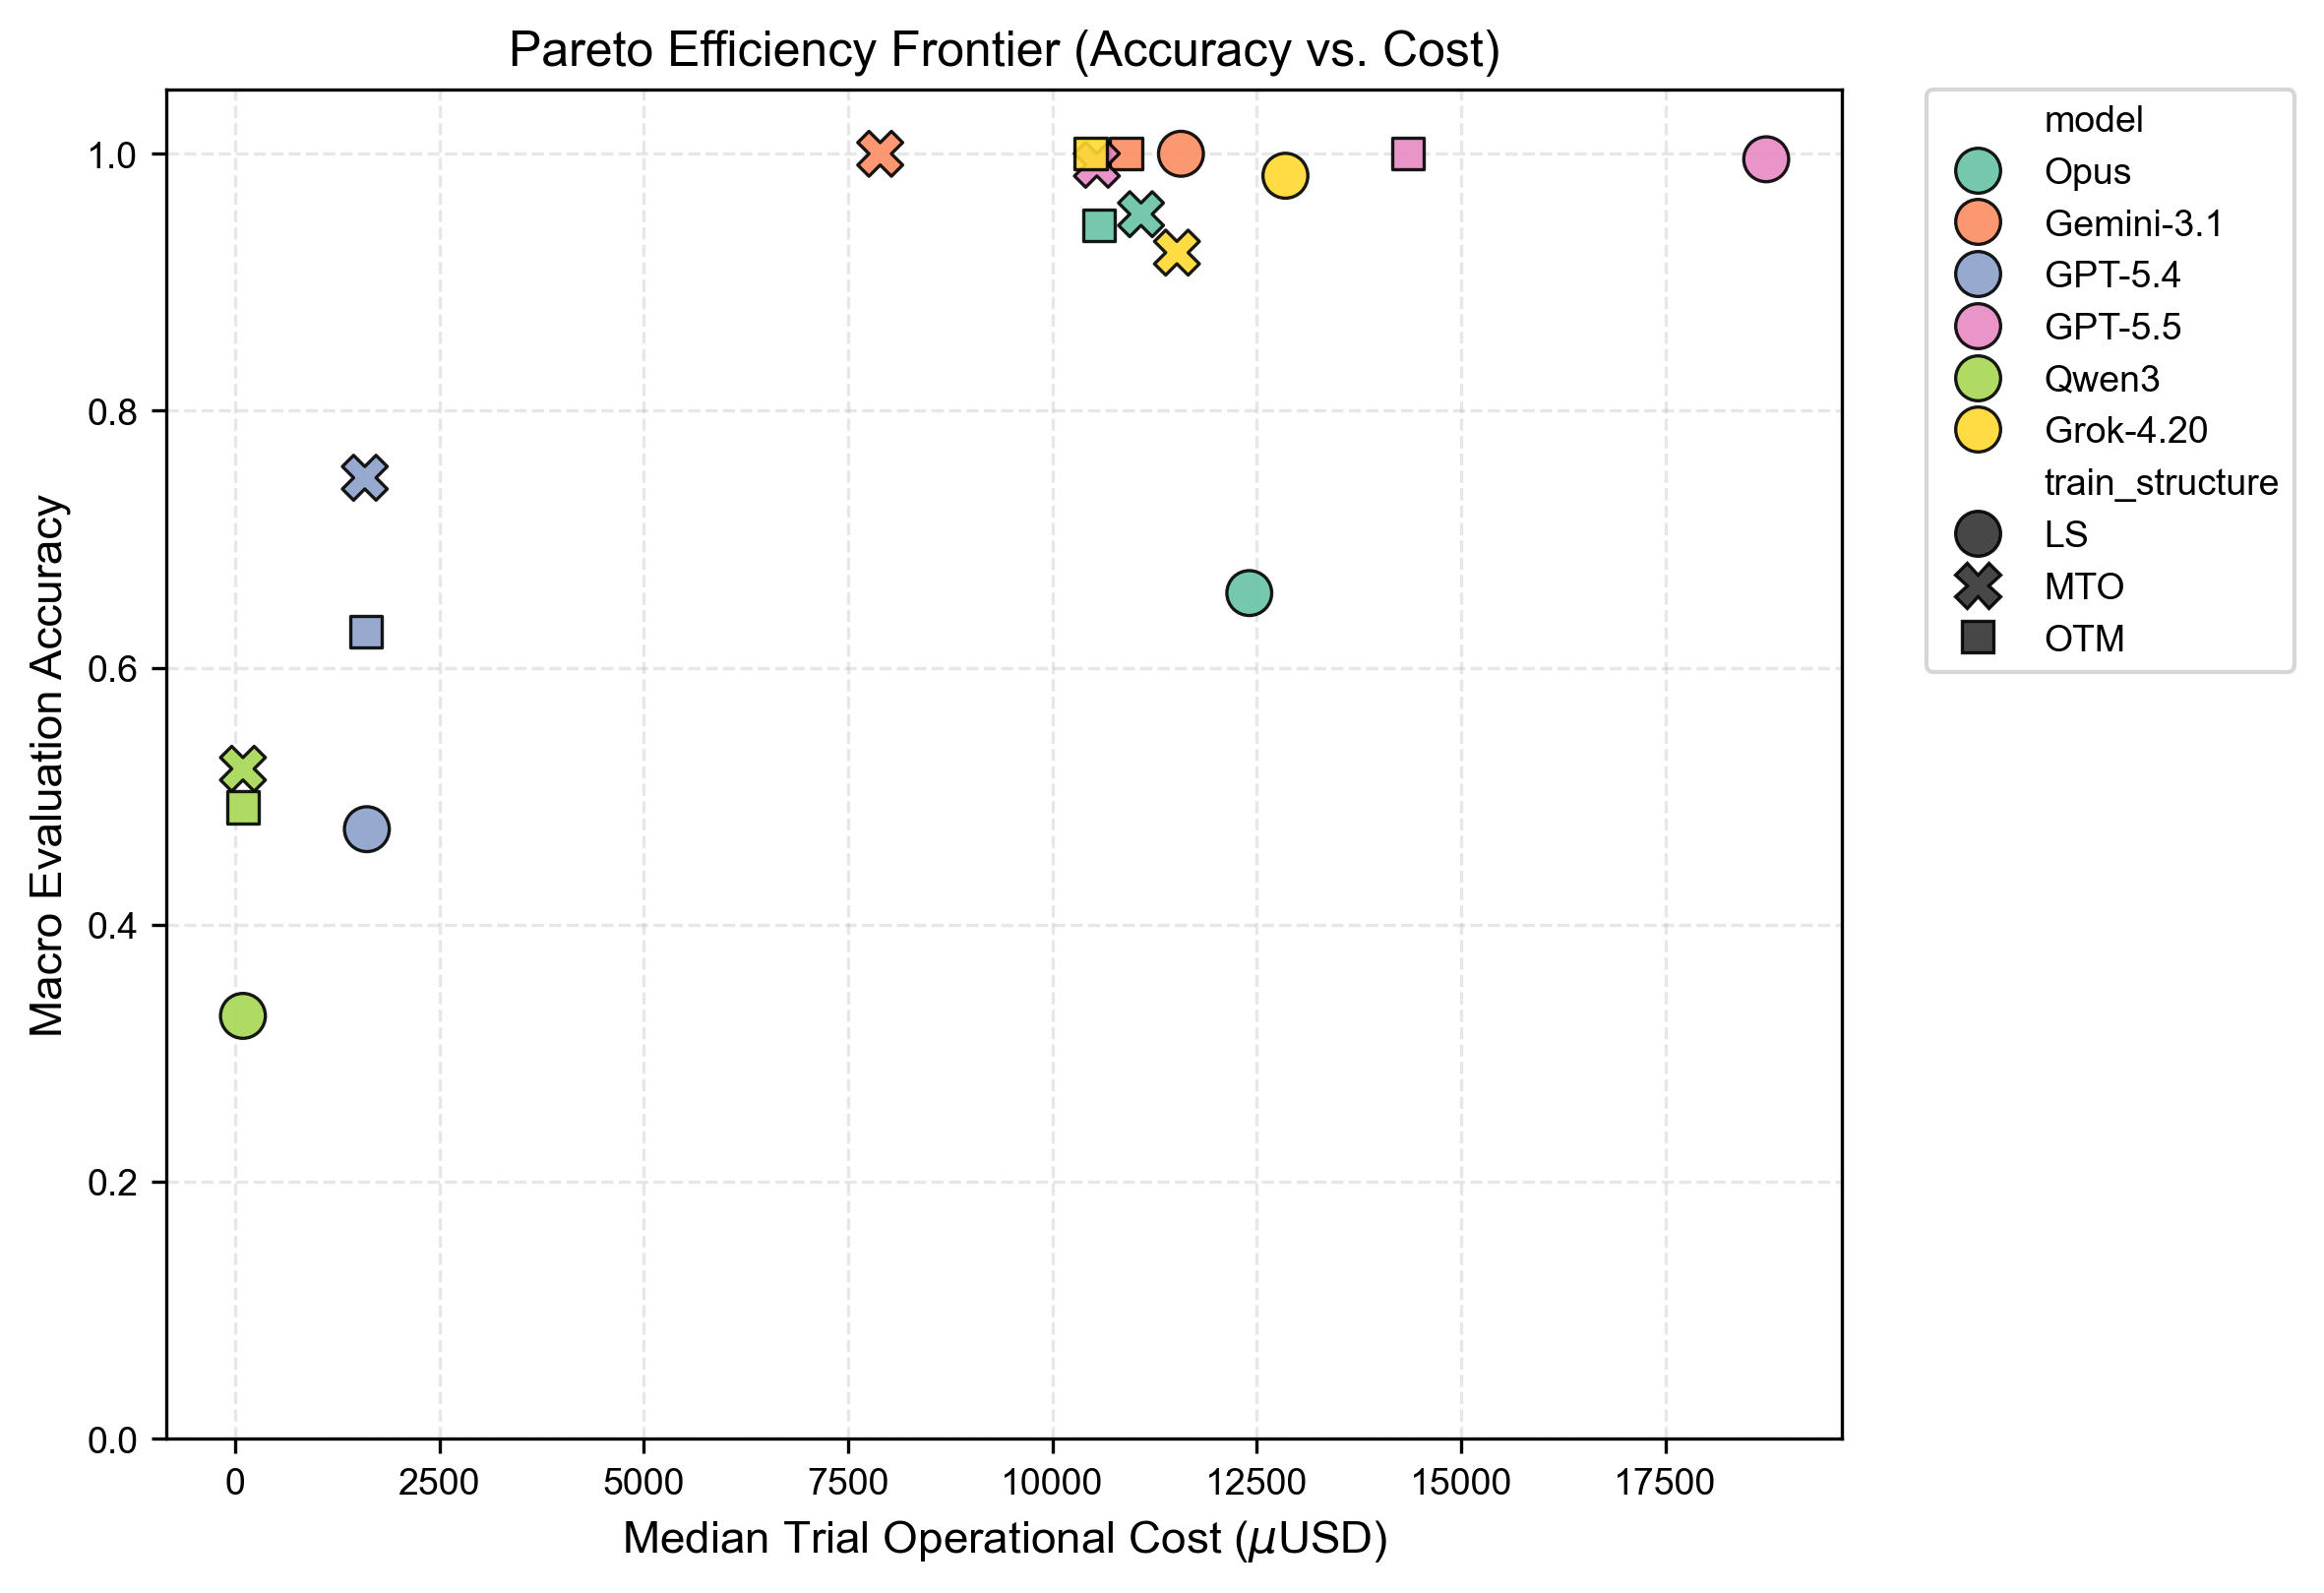

In [24]:
fig1 = display_pareto_efficiency_plot(macro_accuracy_model)

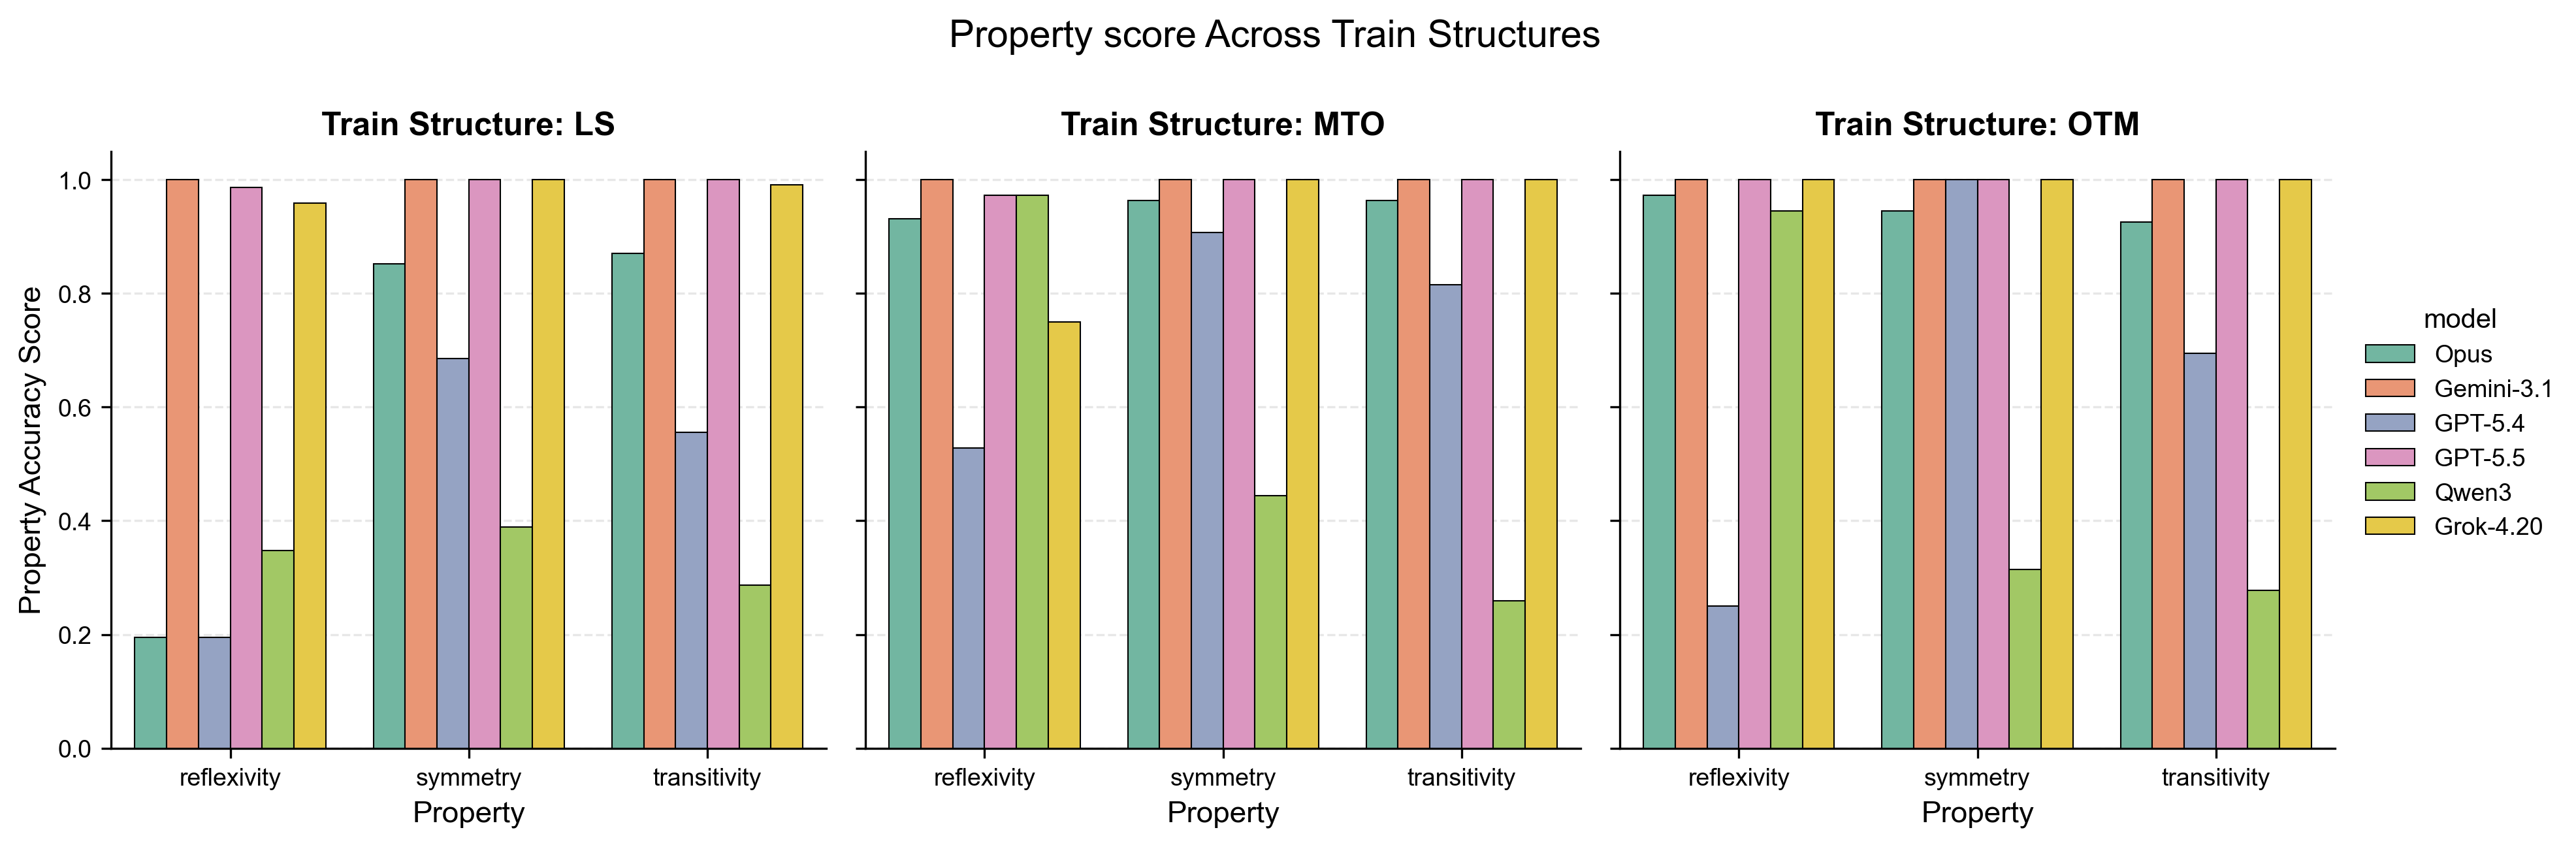

In [25]:
fig2 = display_property_plot(property_accuracy_model)

efficiency for reflexivity


C:\Users\alexi\AppData\Local\Temp\ipykernel_35008\2870218253.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_global["total_cost_microdollars"] = df_global["median_totalTokensCostNanodollars"]/ 1000.0


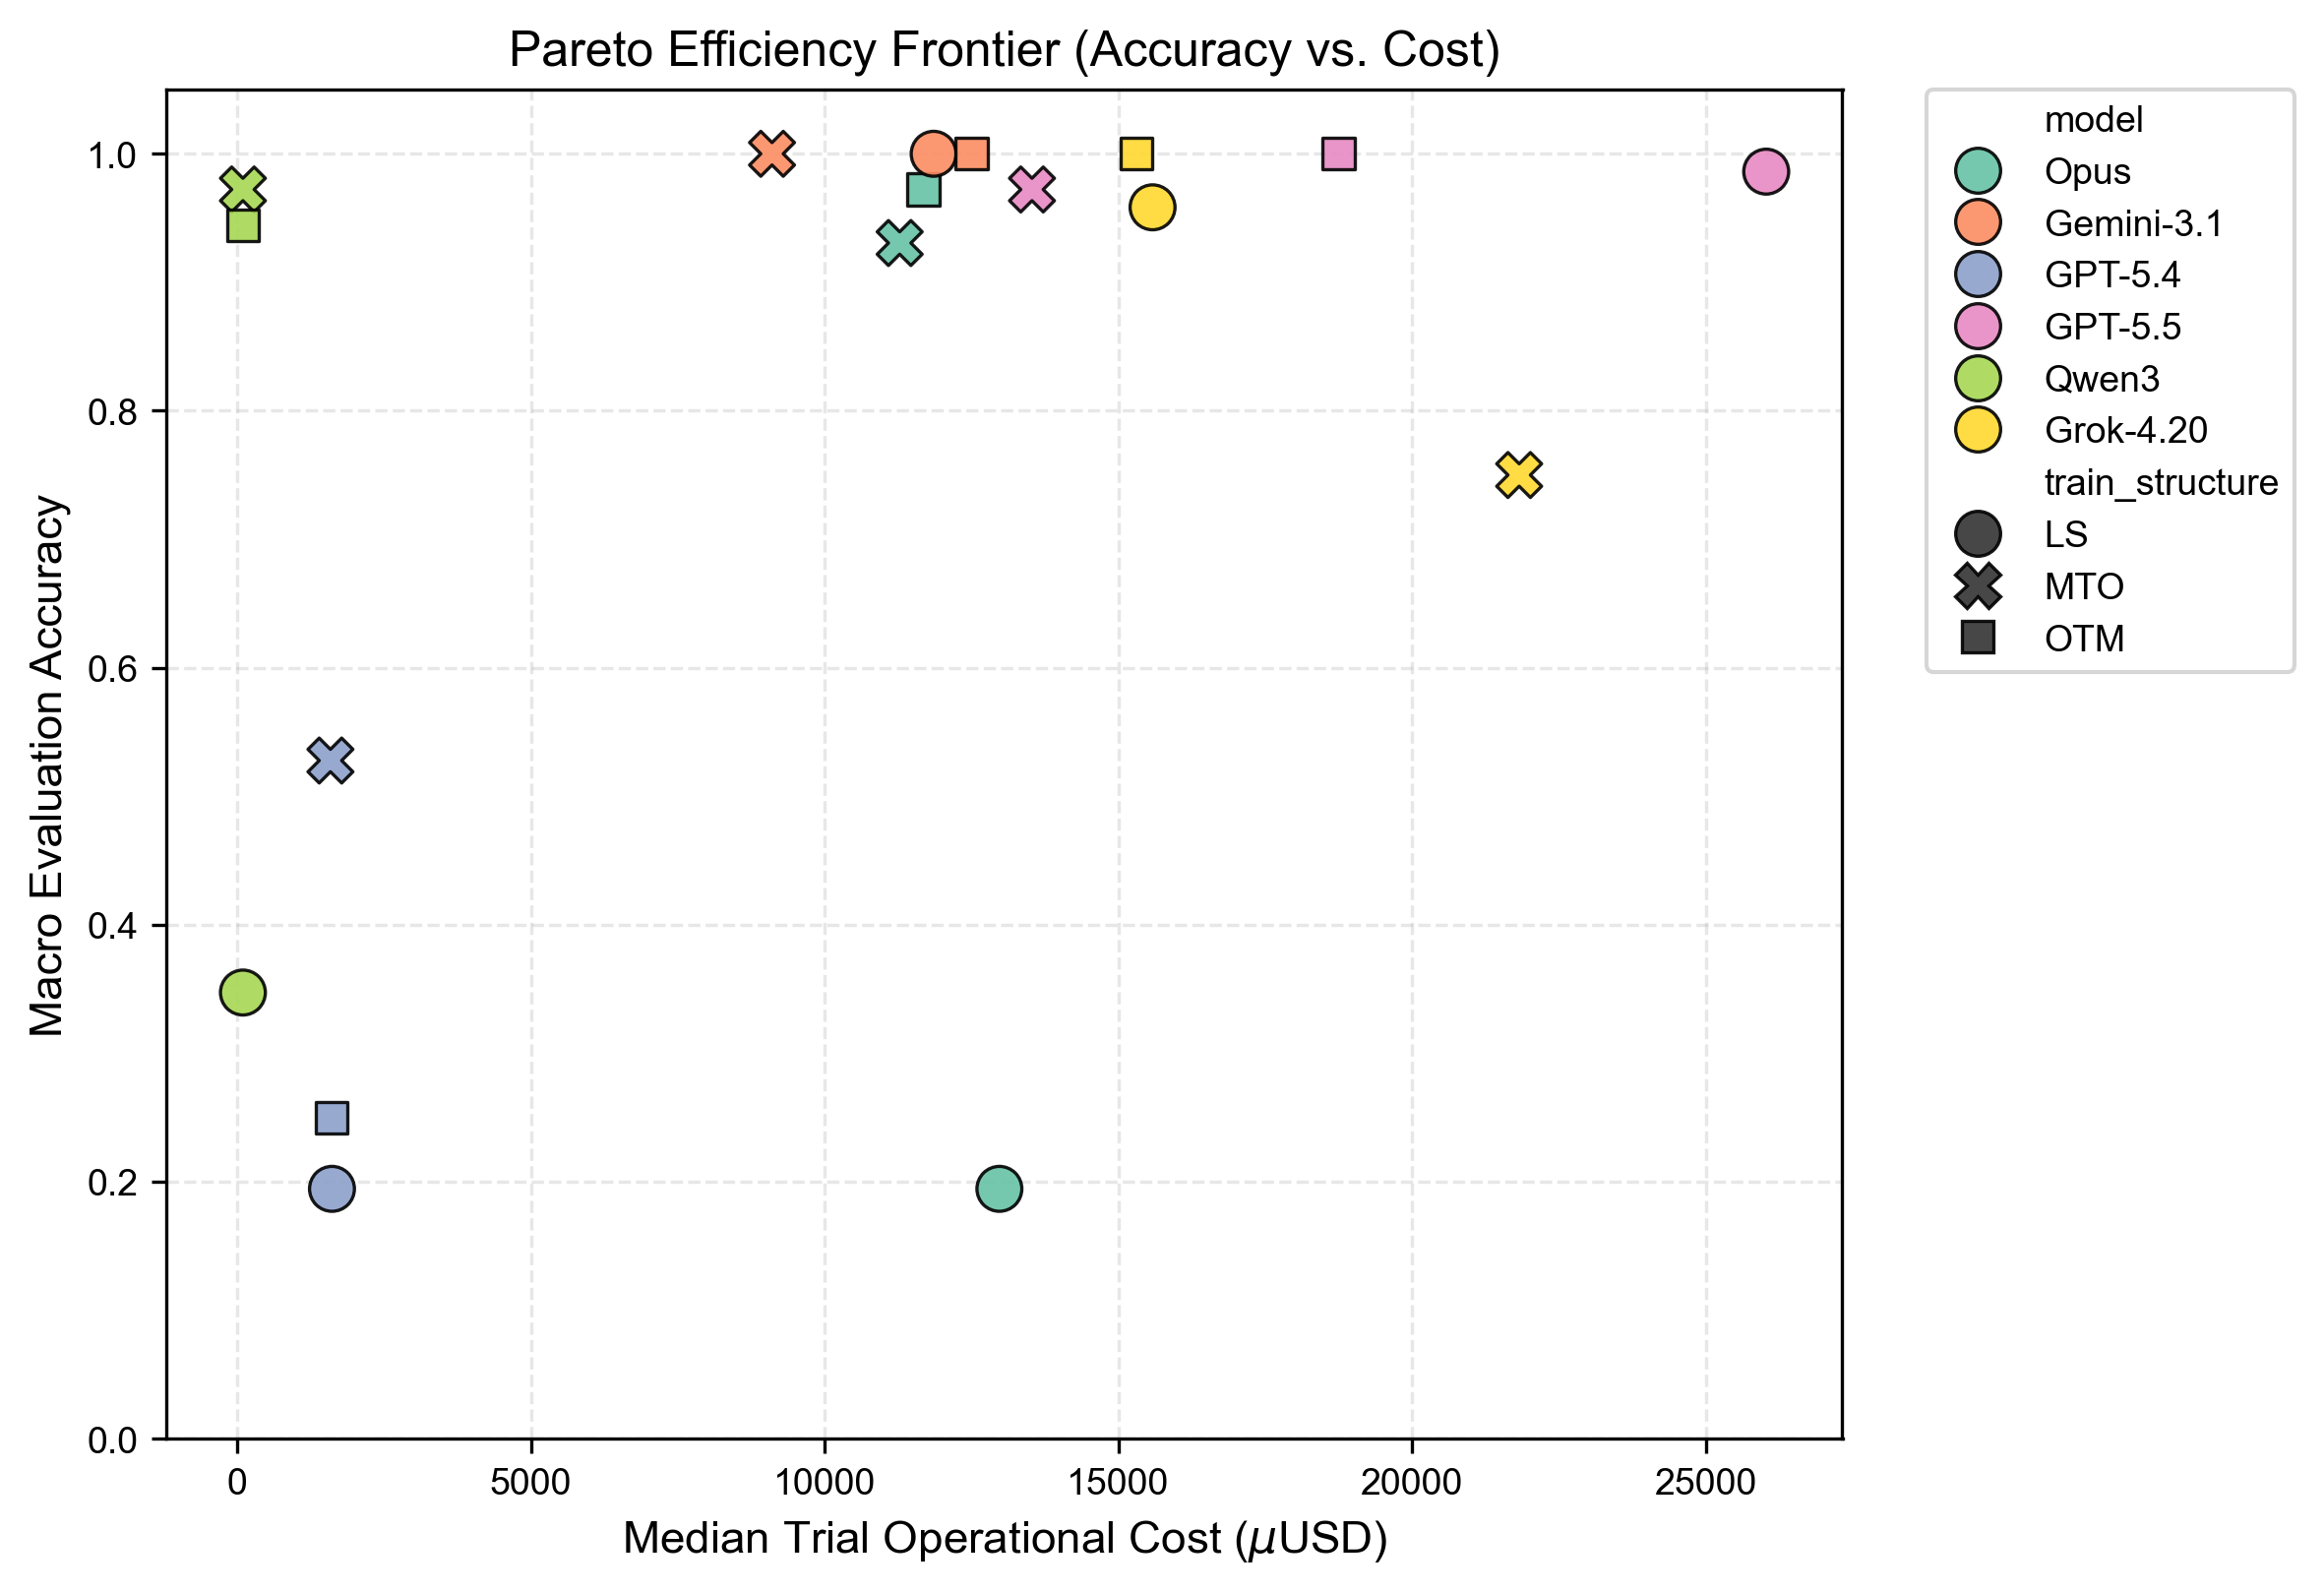

efficiency for symmetry


C:\Users\alexi\AppData\Local\Temp\ipykernel_35008\2870218253.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_global["total_cost_microdollars"] = df_global["median_totalTokensCostNanodollars"]/ 1000.0


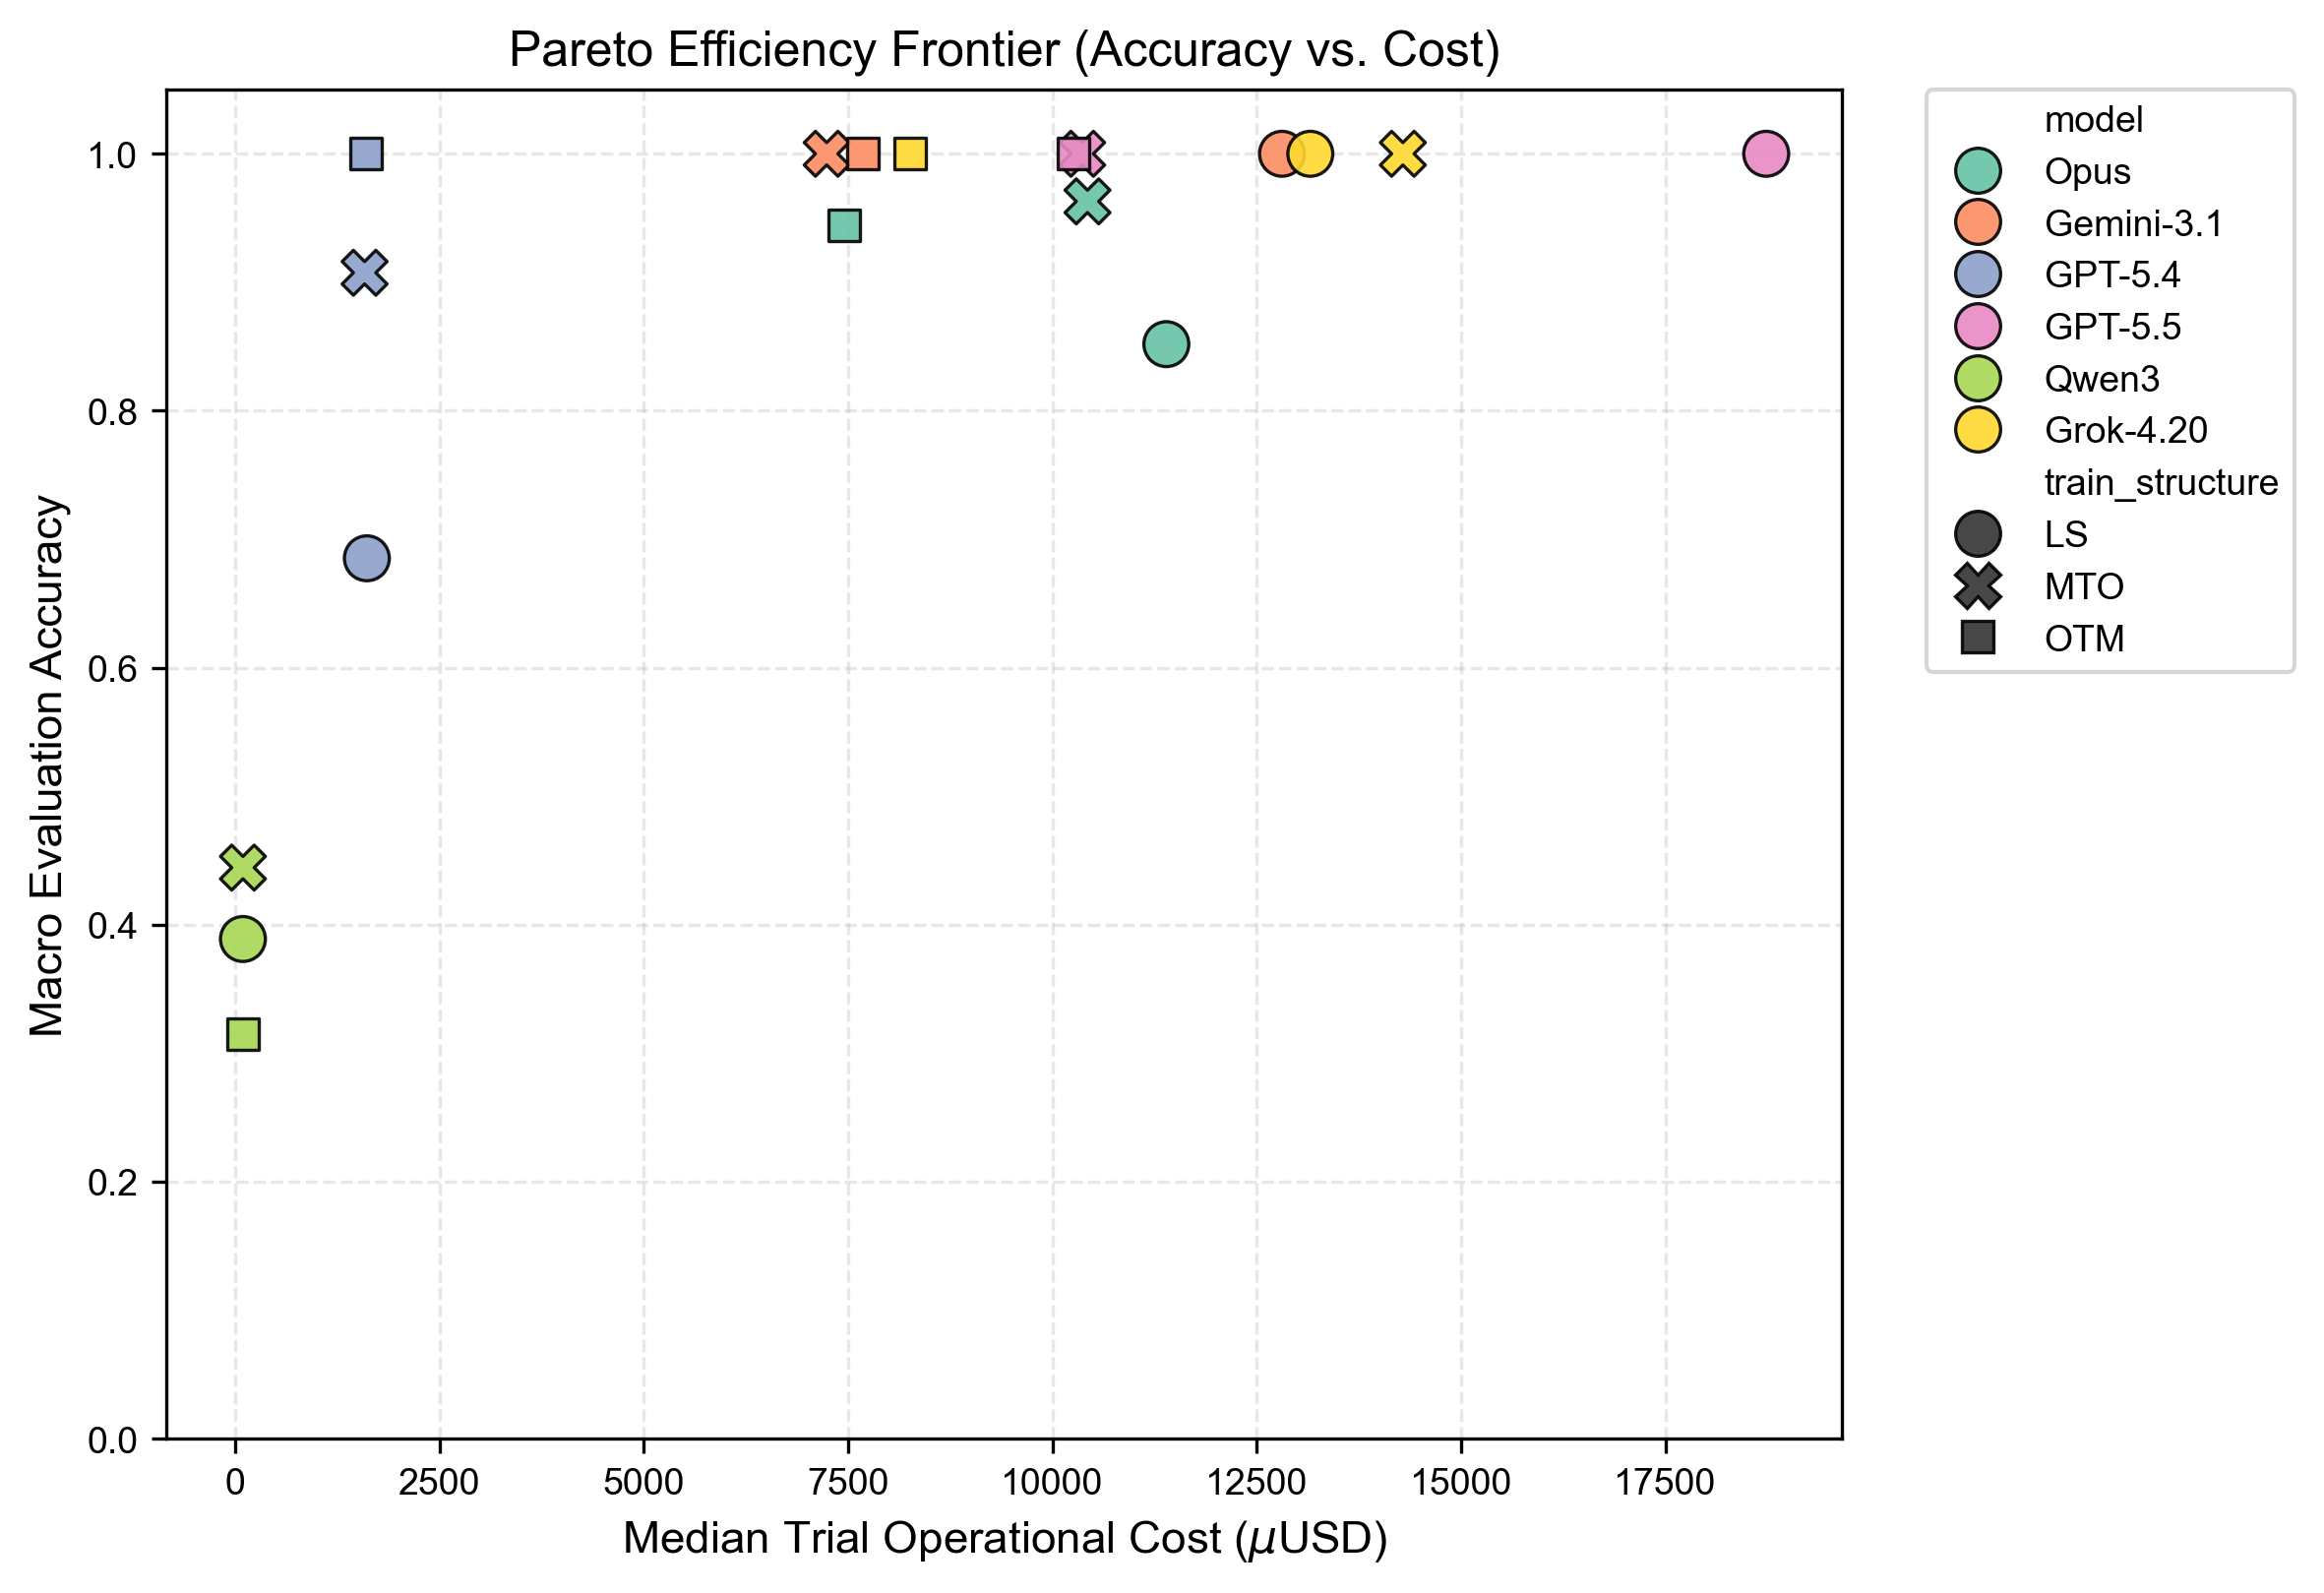

efficiency for transitivity


C:\Users\alexi\AppData\Local\Temp\ipykernel_35008\2870218253.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_global["total_cost_microdollars"] = df_global["median_totalTokensCostNanodollars"]/ 1000.0


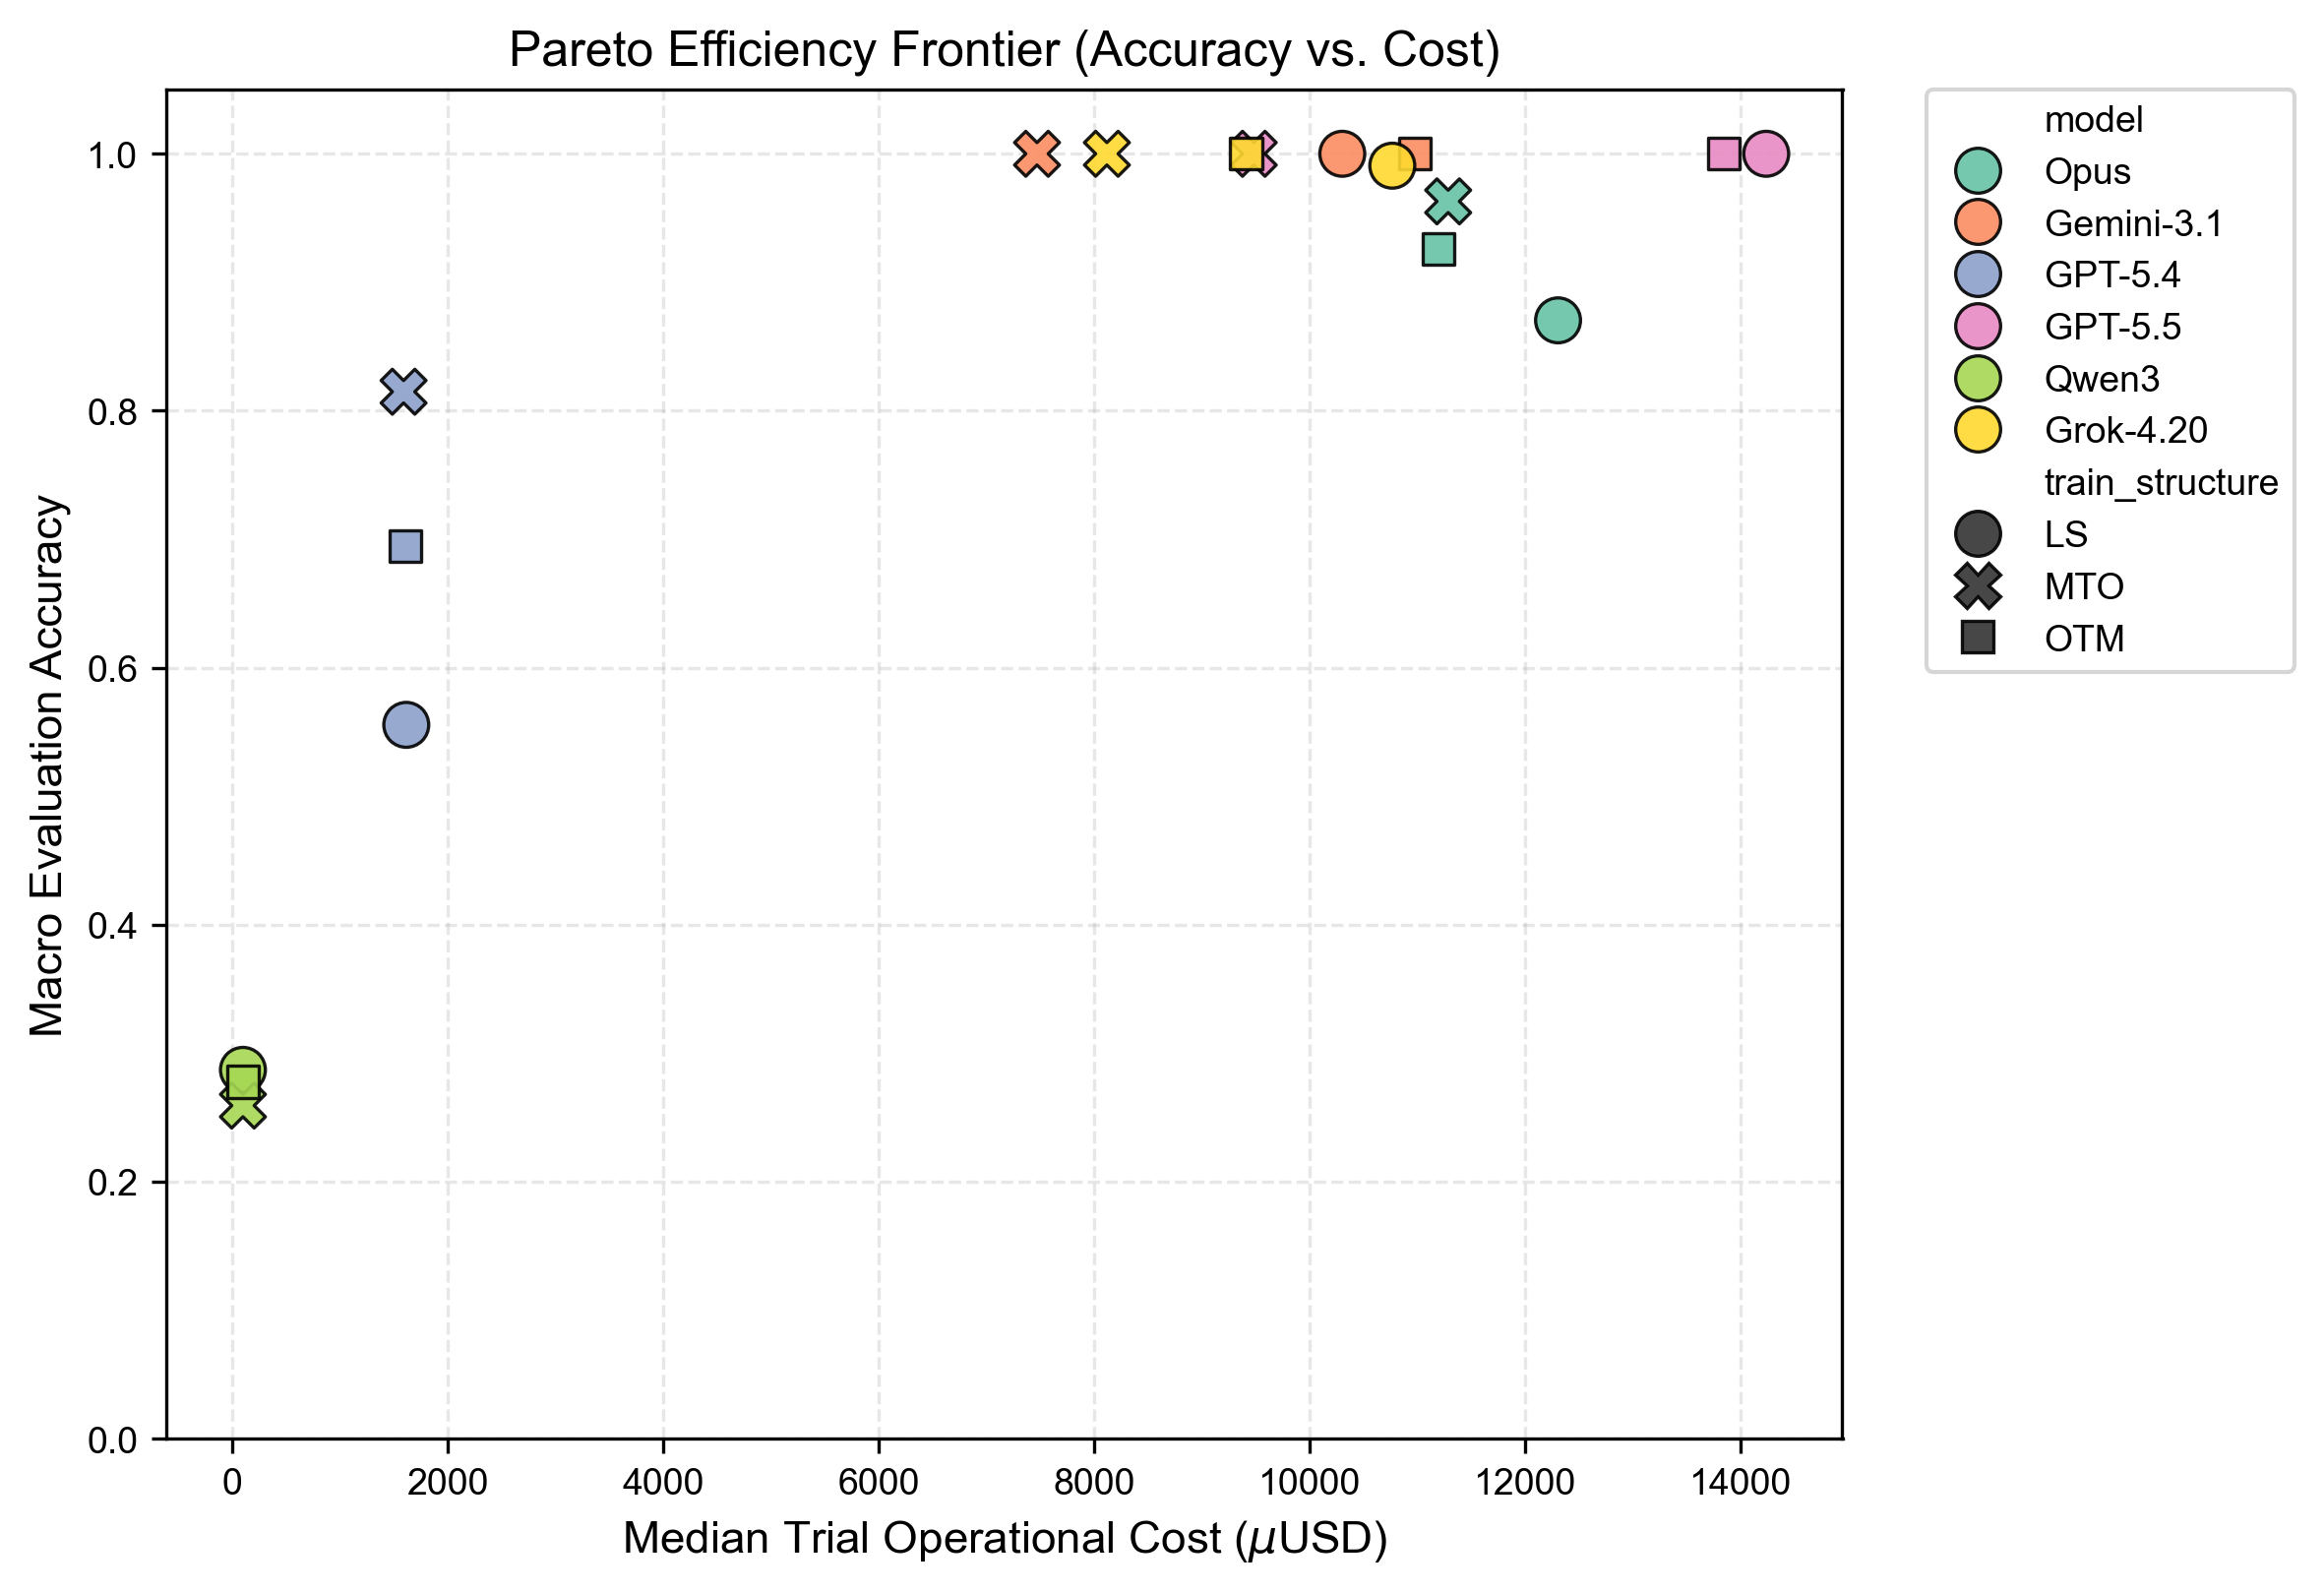

In [26]:
for proprt in ['reflexivity', 'symmetry', 'transitivity']:
    propt_model_dat = property_accuracy_model[property_accuracy_model.sample_subset == proprt]
    print("efficiency for", proprt)
    display_pareto_efficiency_plot(propt_model_dat)

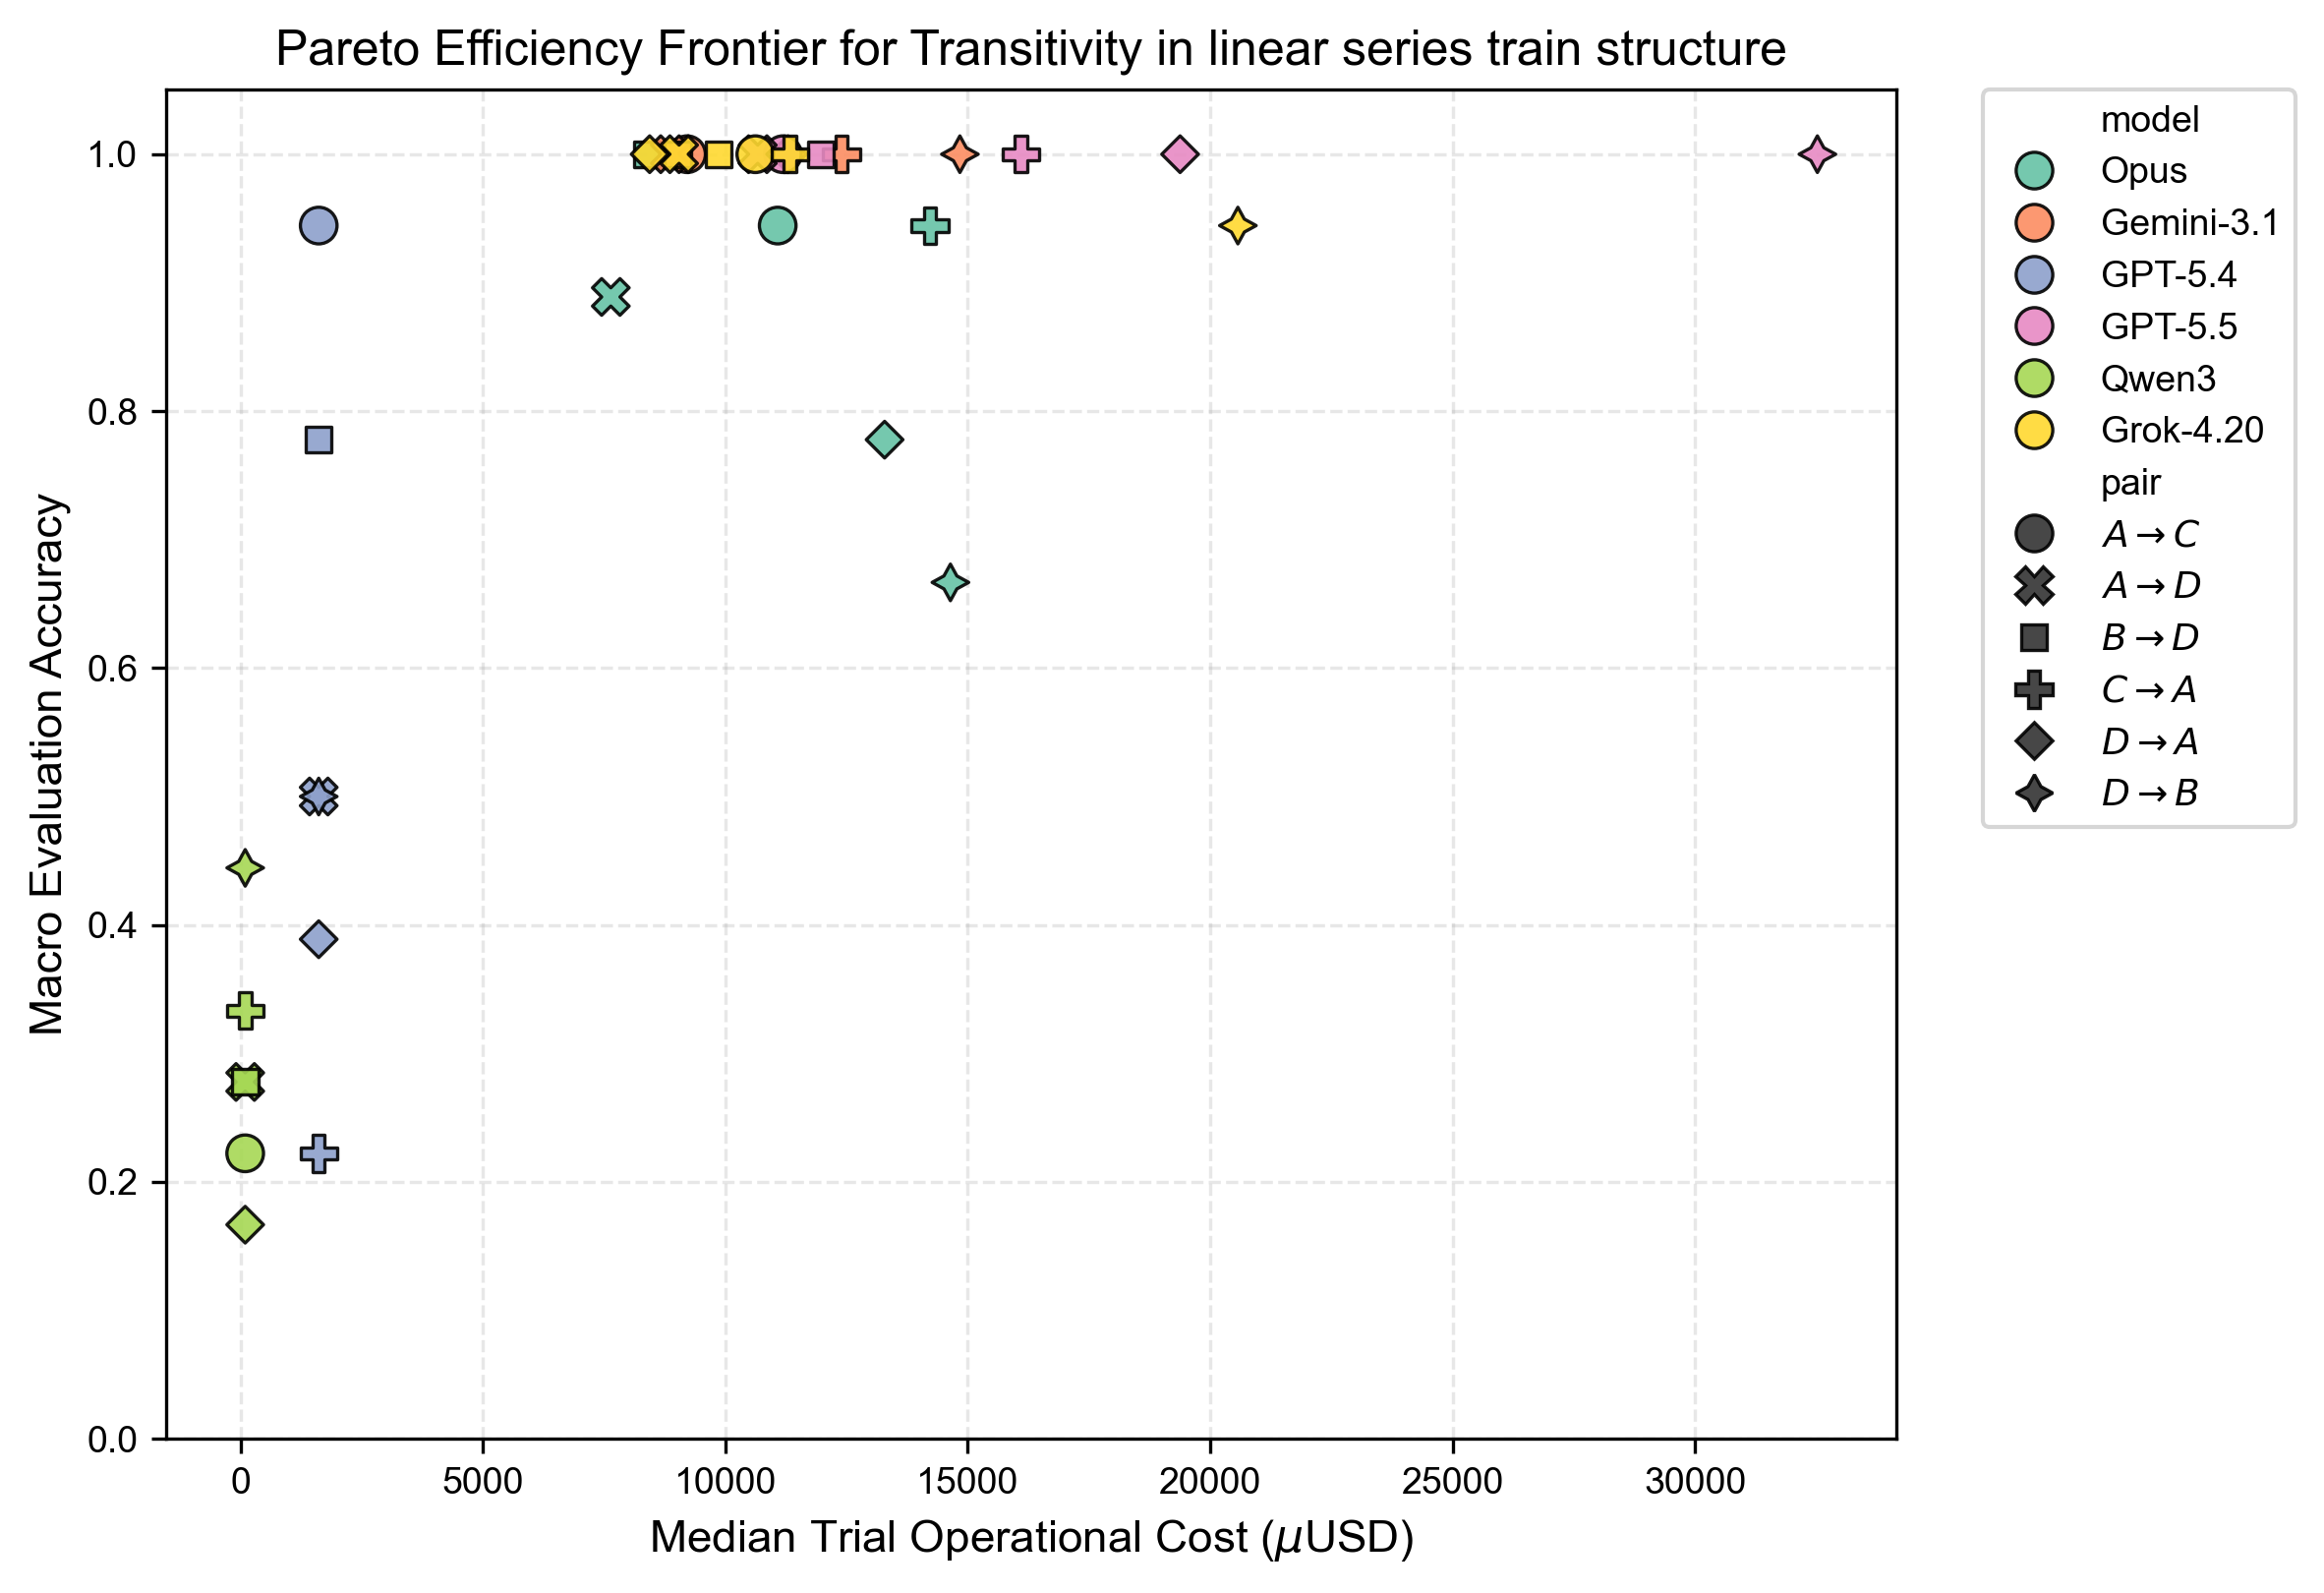

In [27]:
transitive_data = pairwise_accuracy_model.loc[
    (
        pairwise_accuracy_model.train_structure=="LS"
        )&(
        pairwise_accuracy_model.sample_subset=="transitivity"
        ),
    ["model", "pair", "accuracy", "median_totalTokensCostNanodollars"]
    ]


transitive_data["total_cost_microdollars"] = transitive_data["median_totalTokensCostNanodollars"]/ 1000.0

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.grid(True, linestyle="--", alpha=0.3, zorder=0)

palette = sns.color_palette("Set2", n_colors=transitive_data["model"].nunique())

# Scatter Plot implementation
sns.scatterplot(
    data=transitive_data,
    x="total_cost_microdollars",
    y="accuracy",
    hue="model",
    style="pair",
    # style_order=train_structure_order,
    palette=palette,
    s=80,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
    ax=ax
)

ax.set_title("Pareto Efficiency Frontier for Transitivity in linear series train structure")
ax.set_xlabel(r"Median Trial Operational Cost ($\mu$USD)")
ax.set_ylabel("Macro Evaluation Accuracy")
ax.set_ylim(0, 1.05)

# Place legend cleanly outside of data boundaries
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()

# Display the figure inline using IPython context to preserve memory pointers
display(fig)
plt.close(fig) # Closes active state to avoid duplicate rendering artifacts

In [28]:
print(transitive_data[["model", "accuracy", "pair", "total_cost_microdollars"]].to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{llrlr}
\toprule
 & model & accuracy & pair & total_cost_microdollars \\
\midrule
7 & Opus & 0.94 & $A \to C$ & 11080.00 \\
8 & Opus & 0.89 & $A \to D$ & 7637.50 \\
9 & Opus & 1.00 & $B \to D$ & 8385.00 \\
10 & Opus & 0.94 & $C \to A$ & 14222.50 \\
11 & Opus & 0.78 & $D \to A$ & 13285.00 \\
12 & Opus & 0.67 & $D \to B$ & 14642.50 \\
98 & Gemini-3.1 & 1.00 & $A \to C$ & 9210.00 \\
99 & Gemini-3.1 & 1.00 & $A \to D$ & 8856.00 \\
100 & Gemini-3.1 & 1.00 & $B \to D$ & 9018.00 \\
101 & Gemini-3.1 & 1.00 & $C \to A$ & 12396.00 \\
102 & Gemini-3.1 & 1.00 & $D \to A$ & 11292.00 \\
103 & Gemini-3.1 & 1.00 & $D \to B$ & 14838.00 \\
137 & GPT-5.4 & 0.94 & $A \to C$ & 1612.50 \\
138 & GPT-5.4 & 0.50 & $A \to D$ & 1612.50 \\
139 & GPT-5.4 & 0.78 & $B \to D$ & 1612.50 \\
140 & GPT-5.4 & 0.22 & $C \to A$ & 1612.50 \\
141 & GPT-5.4 & 0.39 & $D \to A$ & 1612.50 \\
142 & GPT-5.4 & 0.50 & $D \to B$ & 1612.50 \\
176 & GPT-5.5 & 1.00 & $A \to C$ & 11187.50 \\
177 & GPT-5.5 & 1.00 & $A \to D$